# Predicting Loan Payback - Classification

Bu projede, Kaggle Playground Series S5E11 kapsamında verilen veri seti kullanılarak bir sınıflandırma problemi çözülmesi amaçlanmıştır. Amaç, farklı makine öğrenmesi algoritmalarını eğitip karşılaştırarak veri içerisindeki örüntüleri en doğru şekilde öğrenen ve yüksek tahmin başarısı sağlayan modeli belirlemektir.

In this project, a classification task was carried out using the dataset provided in the Kaggle Playground Series S5E11 competition. The goal was to train and compare various machine learning algorithms to identify the model that best captures patterns in the data and achieves high predictive performance.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.ensemble import VotingClassifier, StackingClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import RidgeClassifier
from sklearn.neighbors import RadiusNeighborsClassifier

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [3]:
print(train.shape)
print(test.shape)

(593994, 13)
(254569, 12)


In [3]:
df=pd.concat([train,test]) 

### EDA

In [5]:
df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 848563 entries, 0 to 254568
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    848563 non-null  int64  
 1   annual_income         848563 non-null  float64
 2   debt_to_income_ratio  848563 non-null  float64
 3   credit_score          848563 non-null  int64  
 4   loan_amount           848563 non-null  float64
 5   interest_rate         848563 non-null  float64
 6   gender                848563 non-null  object 
 7   marital_status        848563 non-null  object 
 8   education_level       848563 non-null  object 
 9   employment_status     848563 non-null  object 
 10  loan_purpose          848563 non-null  object 
 11  grade_subgrade        848563 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 90.6+ MB


In [7]:
df.isnull().sum()

id                           0
annual_income                0
debt_to_income_ratio         0
credit_score                 0
loan_amount                  0
interest_rate                0
gender                       0
marital_status               0
education_level              0
employment_status            0
loan_purpose                 0
grade_subgrade               0
loan_paid_back          254569
dtype: int64

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,848563.0,424281.000000,244959.182573,0.000,212140.500,424281.000,636421.500,848562.000
annual_income,848563.0,48218.466144,26714.243232,6002.430,27939.785,46552.600,61003.900,393381.740
debt_to_income_ratio,848563.0,0.120662,0.068576,0.011,0.072,0.096,0.156,0.627
credit_score,848563.0,680.952514,55.484775,395.000,646.000,682.000,719.000,849.000
loan_amount,848563.0,15019.234385,6925.217352,500.050,10275.010,15000.220,18851.520,48959.950
interest_rate,848563.0,12.355139,2.011555,3.200,10.990,12.370,13.680,21.290
loan_paid_back,593994.0,0.798820,0.400883,0.000,1.000,1.000,1.000,1.000


In [9]:
df.head(10)

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0
5,5,44940.30,0.058,653,12159.92,12.24,Male,Single,Bachelor's,Employed,Other,D1,1.0
6,6,61574.16,0.042,696,16907.71,13.52,Other,Single,High School,Self-employed,Debt consolidation,C5,1.0
7,7,45953.31,0.100,654,10111.62,12.82,Female,Married,High School,Employed,Home,D1,1.0
8,8,30592.29,0.132,713,7522.36,9.48,Male,Married,Bachelor's,Employed,Education,C5,1.0
9,9,17342.45,0.121,548,9653.48,16.04,Female,Married,Bachelor's,Self-employed,Vacation,F1,1.0


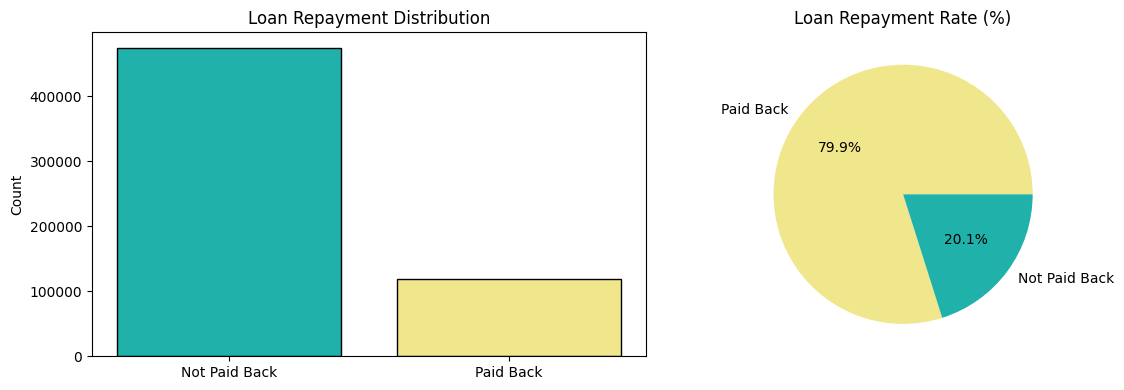

In [10]:
#Loan Paid Back
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
loan_counts = df['loan_paid_back'].value_counts()
plt.bar(['Not Paid Back', 'Paid Back'], loan_counts.values, color=['LightSeaGreen', 'Khaki'], edgecolor='black')
plt.ylabel('Count')
plt.title('Loan Repayment Distribution')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
plt.pie(loan_counts.values, labels=['Paid Back', 'Not Paid Back'], autopct='%1.1f%%', colors=['Khaki', 'LightSeaGreen'])
plt.title('Loan Repayment Rate (%)')

plt.tight_layout()
plt.show()


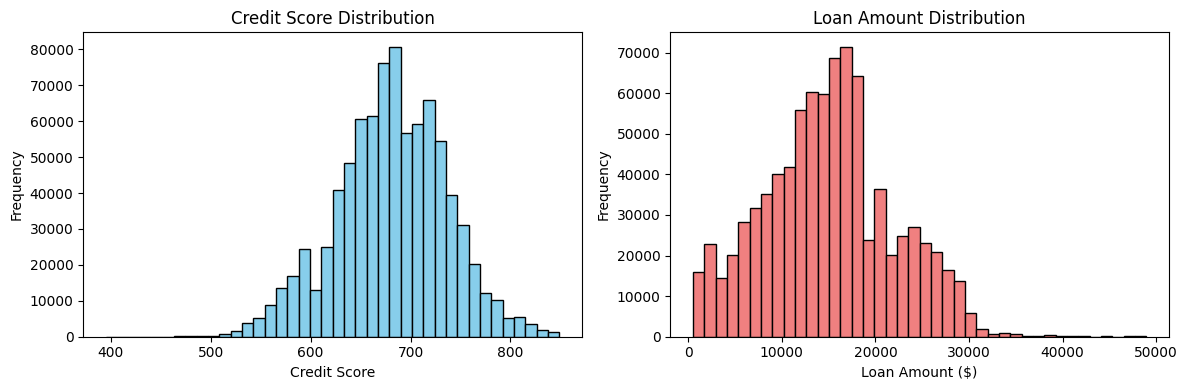

In [11]:
# CREDIT SCORE and Loan Amount Distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df['credit_score'], bins=40, color='skyblue', edgecolor='black')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')
plt.title('Credit Score Distribution')

plt.subplot(1, 2, 2)
plt.hist(df['loan_amount'], bins=40, color='lightcoral', edgecolor='black')
plt.xlabel('Loan Amount ($)')
plt.ylabel('Frequency')
plt.title('Loan Amount Distribution')

plt.tight_layout()
plt.show()

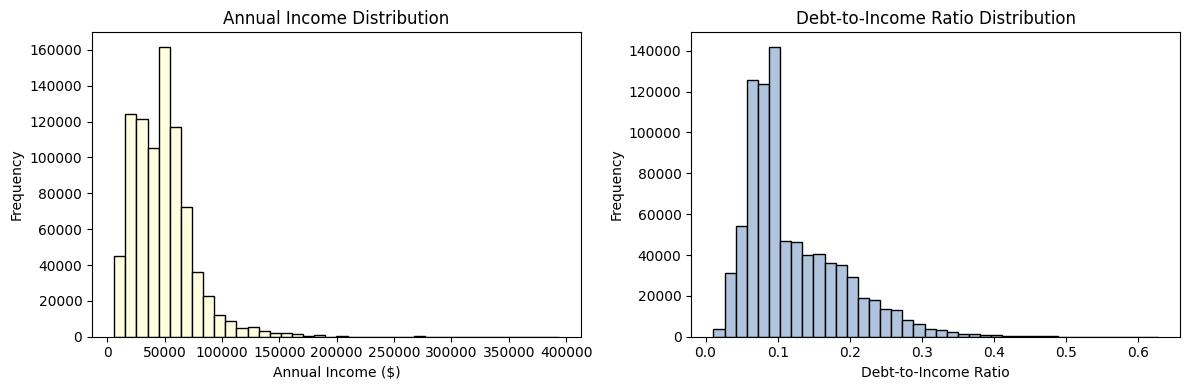

In [12]:
# 3. Annual Income and Debt-to-Income Ratio Distribution

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df['annual_income'], bins=40, color='lightyellow', edgecolor='black')
plt.xlabel('Annual Income ($)')
plt.ylabel('Frequency')
plt.title('Annual Income Distribution')

plt.subplot(1, 2, 2)
plt.hist(df['debt_to_income_ratio'], bins=40, color='lightsteelblue', edgecolor='black')
plt.xlabel('Debt-to-Income Ratio')
plt.ylabel('Frequency')
plt.title('Debt-to-Income Ratio Distribution')

plt.tight_layout()
plt.show()

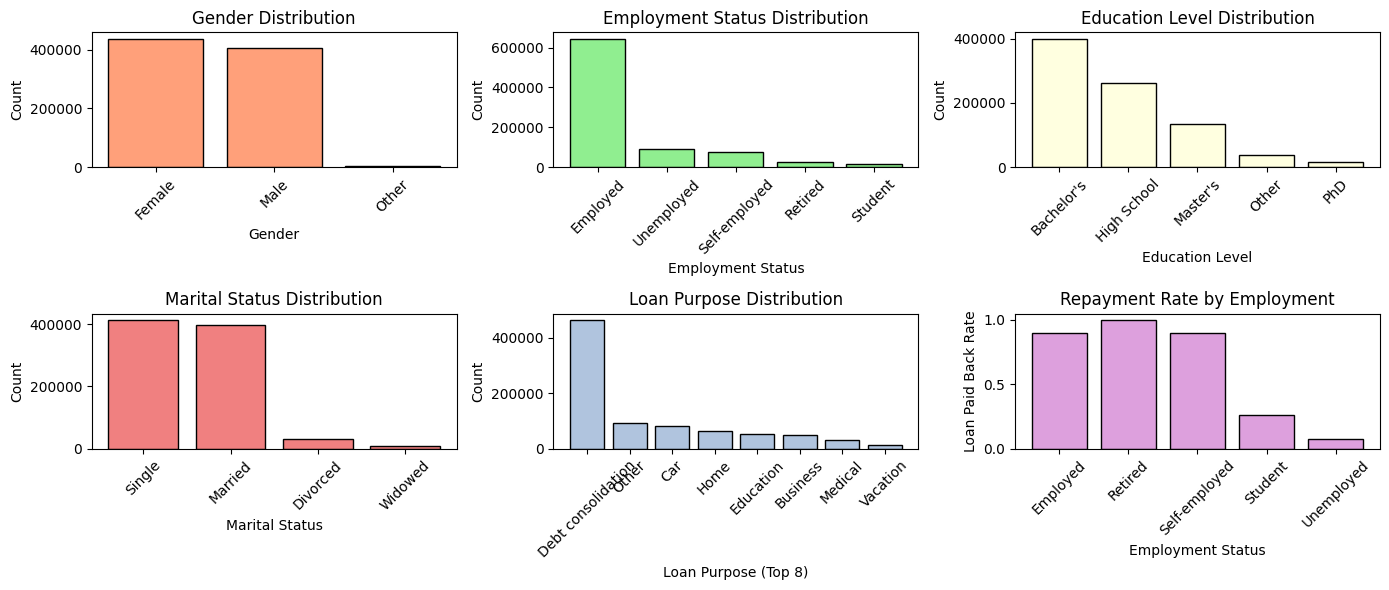

In [13]:
# Categorical fEATURES

plt.figure(figsize=(14, 6))

plt.subplot(2, 3, 1)
plt.bar(df['gender'].value_counts().index, df['gender'].value_counts().values, color='LightSalmon', edgecolor='black')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender Distribution')
plt.xticks(rotation=45)

plt.subplot(2, 3, 2)
plt.bar(df['employment_status'].value_counts().index, df['employment_status'].value_counts().values, color='lightgreen', edgecolor='black')
plt.xlabel('Employment Status')
plt.ylabel('Count')
plt.title('Employment Status Distribution')
plt.xticks(rotation=45)

plt.subplot(2, 3, 3)
plt.bar(df['education_level'].value_counts().index, df['education_level'].value_counts().values, color='lightyellow', edgecolor='black')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.title('Education Level Distribution')
plt.xticks(rotation=45)

plt.subplot(2, 3, 4)
plt.bar(df['marital_status'].value_counts().index, df['marital_status'].value_counts().values, color='lightcoral', edgecolor='black')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.title('Marital Status Distribution')
plt.xticks(rotation=45)

plt.subplot(2, 3, 5)
plt.bar(df['loan_purpose'].value_counts().head(8).index, df['loan_purpose'].value_counts().head(8).values, color='lightsteelblue', edgecolor='black')
plt.xlabel('Loan Purpose (Top 8)')
plt.ylabel('Count')
plt.title('Loan Purpose Distribution')
plt.xticks(rotation=45)

plt.subplot(2, 3, 6)
loan_by_employment = df.groupby('employment_status')['loan_paid_back'].mean()
plt.bar(loan_by_employment.index, loan_by_employment.values, color='plum', edgecolor='black')
plt.xlabel('Employment Status')
plt.ylabel('Loan Paid Back Rate')
plt.title('Repayment Rate by Employment')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [14]:
#Correlation by loan_paid_back
abs(df.corr(numeric_only=True))['loan_paid_back'].sort_values(ascending=False)

loan_paid_back          1.000000
debt_to_income_ratio    0.335680
credit_score            0.234560
interest_rate           0.131184
annual_income           0.006326
loan_amount             0.003762
id                      0.001387
Name: loan_paid_back, dtype: float64

### Feature Engineering

In [4]:
# Gender Encoding
gender_map = {'Female': 0, 'Male': 1, 'Other': 2}
df['gender'] = df['gender'].map(gender_map)

# Employment Status Encoding
employment_map = {
    'Employed': 0,
    'Self-employed': 1,
    'Unemployed': 2,
    'Retired': 3,
    'Student': 4 
}

df['employment_status'] = df['employment_status'].map(employment_map)

# Education Level Encoding
education_map = {
    'High School': 0,
    'Bachelor\'s': 1,
    'Master\'s': 2,
    'PhD': 3,
    'Other': 4
}
df['education_level'] = df['education_level'].map(education_map)

# Marital Status Encoding
marital_map = {
    'Single': 0,
    'Married': 1,
    'Divorced': 2,
    'Widowed': 3,
    'Other': 4
}
df['marital_status'] = df['marital_status'].map(marital_map)


In [16]:
df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,0,0,0,1,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,1,1,2,0,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,1,0,0,0,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,0,0,0,0,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,1,1,0,0,Other,D1,1.0


In [17]:
df.grade_subgrade.value_counts()

grade_subgrade
C3    84105
C4    79669
C2    77777
C1    76177
C5    76094
D1    52750
D3    52333
D4    50087
D2    49205
D5    46024
B2    21764
B1    20412
B3    19960
B5    19951
B4    19912
E4    11427
E3    10140
E1     9795
E2     9105
E5     8694
F5     8509
F4     7974
F1     7855
F2     7432
F3     7282
A5     3477
A3     2980
A2     2949
A4     2417
A1     2307
Name: count, dtype: int64

In [5]:
#grade_subgrade
df['grade'] = df['grade_subgrade'].str[0]  # C, D, B, E, F, A
df['subgrade'] = df['grade_subgrade'].str[1:].astype(int)  # 1, 2, 3, 4, 5

# Grade ->numeric (A=5, B=4, C=3, D=2, E=1, F=0)
grade_map = {'A': 5, 'B': 4, 'C': 3, 'D': 2, 'E': 1, 'F': 0}
df['grade'] = df['grade'].map(grade_map)

# (grade + subgrade)
df['grade_subgrade'] = df['grade'] * 10 + df['subgrade']

In [19]:
df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back,grade,subgrade
0,0,29367.99,0.084,736,2528.42,13.67,0,0,0,1,Other,33,1.0,3,3
1,1,22108.02,0.166,636,4593.10,12.92,1,1,2,0,Debt consolidation,23,0.0,2,3
2,2,49566.20,0.097,694,17005.15,9.76,1,0,0,0,Debt consolidation,35,1.0,3,5
3,3,46858.25,0.065,533,4682.48,16.10,0,0,0,0,Debt consolidation,1,1.0,0,1
4,4,25496.70,0.053,665,12184.43,10.21,1,1,0,0,Other,21,1.0,2,1


In [20]:
abs(df.corr(numeric_only=True))['loan_paid_back'].sort_values(ascending=False)

loan_paid_back          1.000000
employment_status       0.454180
debt_to_income_ratio    0.335680
credit_score            0.234560
grade                   0.218781
grade_subgrade          0.215584
interest_rate           0.131184
gender                  0.007356
annual_income           0.006326
subgrade                0.006278
loan_amount             0.003762
education_level         0.002863
id                      0.001387
marital_status          0.001224
Name: loan_paid_back, dtype: float64

In [6]:
# DTI risk (high DTI = risk)
df['high_dti'] = (df['debt_to_income_ratio'] > 0.2).astype(int)

# Dlow_credit_score riski
df['low_credit_score'] = (df['credit_score'] < 650).astype(int)

# high_interest_rate risk
df['high_interest_rate'] = (df['interest_rate'] > 13).astype(int)

In [7]:
df['credit_score_category'] = pd.cut(df['credit_score'], 
                                     bins=[0, 580, 670, 740, 850],
                                     labels=['Poor', 'Fair', 'Good', 'Excellent'])

# DTI Risk Kategorileri
df['dti_category'] = pd.cut(df['debt_to_income_ratio'], 
                            bins=[0, 0.1, 0.2, 0.3, 1],
                            labels=['Low', 'Medium', 'High', 'Very High'])

# Loan Amount Kategorileri
df['loan_amount_category'] = pd.cut(df['loan_amount'], 
                                    bins=[0, 10000, 15000, 20000, 50000],
                                    labels=['Small', 'Medium', 'Large', 'Very Large'])

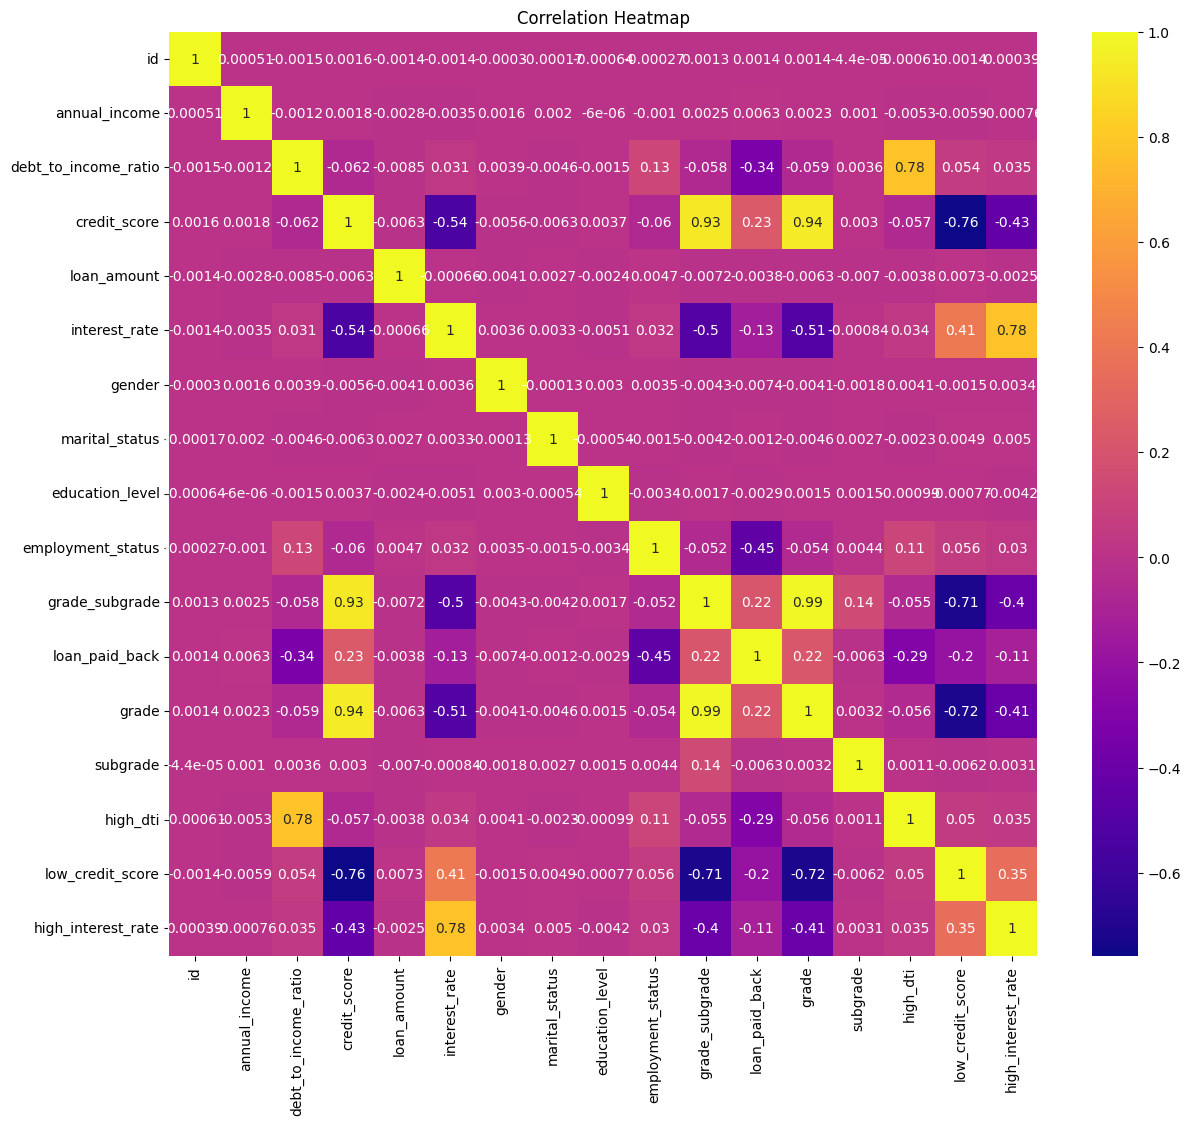

In [23]:
#Correlation Heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='plasma')
plt.title('Correlation Heatmap')
plt.show()

In [24]:
abs(df.corr(numeric_only=True))['loan_paid_back'].sort_values(ascending=False)

loan_paid_back          1.000000
employment_status       0.454180
debt_to_income_ratio    0.335680
high_dti                0.292713
credit_score            0.234560
grade                   0.218781
grade_subgrade          0.215584
low_credit_score        0.196654
interest_rate           0.131184
high_interest_rate      0.112747
gender                  0.007356
annual_income           0.006326
subgrade                0.006278
loan_amount             0.003762
education_level         0.002863
id                      0.001387
marital_status          0.001224
Name: loan_paid_back, dtype: float64

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 848563 entries, 0 to 254568
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   id                     848563 non-null  int64   
 1   annual_income          848563 non-null  float64 
 2   debt_to_income_ratio   848563 non-null  float64 
 3   credit_score           848563 non-null  int64   
 4   loan_amount            848563 non-null  float64 
 5   interest_rate          848563 non-null  float64 
 6   gender                 848563 non-null  int64   
 7   marital_status         848563 non-null  int64   
 8   education_level        848563 non-null  int64   
 9   employment_status      848563 non-null  int64   
 10  loan_purpose           848563 non-null  object  
 11  grade_subgrade         848563 non-null  int64   
 12  loan_paid_back         593994 non-null  float64 
 13  grade                  848563 non-null  int64   
 14  subgrade               84

In [8]:
top_features = [
'employment_status',       
'debt_to_income_ratio' ,   
'high_dti' ,              
'credit_score',            
'grade'  ,         
'grade_subgrade',          
'low_credit_score' ,       
'interest_rate',           
'high_interest_rate',
'loan_purpose',
'credit_score_category',
'dti_category',
'loan_amount_category'
]

In [9]:
train = df[df['loan_paid_back'].notna()]
test  = df[df['loan_paid_back'].isna()]

In [10]:
x = train[top_features]
y = train['loan_paid_back']

x_final_test = test[top_features]

In [11]:
x_all = pd.concat([x, x_final_test])
x_all = pd.get_dummies(x_all, drop_first=True)

In [12]:
x = x_all.iloc[:len(x)]
x_final_test = x_all.iloc[len(x):]

In [13]:
print(x.columns.tolist())

['employment_status', 'debt_to_income_ratio', 'high_dti', 'credit_score', 'grade', 'grade_subgrade', 'low_credit_score', 'interest_rate', 'high_interest_rate', 'loan_purpose_Car', 'loan_purpose_Debt consolidation', 'loan_purpose_Education', 'loan_purpose_Home', 'loan_purpose_Medical', 'loan_purpose_Other', 'loan_purpose_Vacation', 'credit_score_category_Fair', 'credit_score_category_Good', 'credit_score_category_Excellent', 'dti_category_Medium', 'dti_category_High', 'dti_category_Very High', 'loan_amount_category_Medium', 'loan_amount_category_Large', 'loan_amount_category_Very Large']


In [22]:
print(df.groupby('loan_amount_category')['loan_amount'].agg(['min','max']))

                           min       max
loan_amount_category                    
Small                   500.05   9999.85
Medium                10002.01  15000.00
Large                 15000.01  19997.94
Very Large            20000.21  48959.95


### Model Training

In [14]:
def algo_test(x, y):
    modeller = [
        BernoulliNB(),
        LogisticRegression(max_iter=500, solver='lbfgs'),   
        DecisionTreeClassifier(),
        RandomForestClassifier(),
        GradientBoostingClassifier(),
        KNeighborsClassifier(),
        AdaBoostClassifier(),
        MultinomialNB(),
        XGBClassifier(use_label_encoder=False, eval_metric='logloss', verbosity=0, random_state=42),
        LGBMClassifier(verbose=-1, random_state=42),
        CatBoostClassifier(verbose=0, random_state=42)
    ]
    isimler = [
        "BernoulliNB", 
        "LogisticRegression", 
        "DecisionTreeClassifier", 
        "RandomForestClassifier", 
        "GradientBoostingClassifier", 
        "KNeighborsClassifier", 
        "AdaBoostClassifier", 
        "MultinomialNB",
        "XGBClassifier",
        "LGBMClassifier",
        "CatBoostClassifier"
    ]
    
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state=42)
    
    accuracy, precision, recall, f1, mdl = [], [], [], [], []
    
    print("Veriler hazır, modeller deneniyor...")
    for name, model in zip(isimler, modeller):
        print(f"{name} modeli eğitiliyor...")
        if isinstance(model, MultinomialNB):
            if (np.array(x_train) < 0).any():
                print("Uyarı: MultinomialNB negatif değerlerle çalışmaz, bu model atlanıyor!")
                accuracy.append(np.nan)
                precision.append(np.nan)
                recall.append(np.nan)
                f1.append(np.nan)
                mdl.append(None)
                continue
        try:
            model.fit(x_train, y_train)
            tahmin = model.predict(x_test)
            mdl.append(model)
            accuracy.append(accuracy_score(y_test, tahmin))
            precision.append(precision_score(y_test, tahmin, average="binary"))
            recall.append(recall_score(y_test, tahmin, average="binary"))
            f1.append(f1_score(y_test, tahmin, average="binary"))
            print(confusion_matrix(y_test, tahmin))
        except Exception as e:
            print(f"{name} modeli çalıştırılırken hata oluştu: {e}")
            accuracy.append(np.nan)
            precision.append(np.nan)
            recall.append(np.nan)
            f1.append(np.nan)
            mdl.append(None)
    
    print("Eğitim tamamlandı.")
    
    metrics = pd.DataFrame({
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Model": mdl
    }, index=isimler)

    metrics.sort_values("F1", ascending=False, inplace=True)
    print("En başarılı model:", metrics.dropna().iloc[0].name)
    en_iyi_model = metrics.dropna().iloc[0]["Model"]

    tahmin = en_iyi_model.predict(x_test)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, tahmin))
    print("Classification Report:")
    print(classification_report(y_test, tahmin))

    print("\nDiğer Modeller:")
    print(metrics.drop("Model", axis=1))

    return metrics.drop("Model", axis=1)

In [15]:
algo_test(x,y)

Veriler hazır, modeller deneniyor...
BernoulliNB modeli eğitiliyor...
[[11744 12253]
 [ 7046 87756]]
LogisticRegression modeli eğitiliyor...
[[10791 13206]
 [ 4851 89951]]
DecisionTreeClassifier modeli eğitiliyor...
[[15516  8481]
 [ 9555 85247]]
RandomForestClassifier modeli eğitiliyor...


KeyboardInterrupt: 

In [33]:
best_model= CatBoostClassifier(verbose=0, random_state=42)
best_model.fit(x,y)

CatBoostClassifier(random_state=42, verbose=0)

In [34]:
prediction = best_model.predict_proba(x_final_test, verbose=0)[:,1]

In [35]:
sonuc = pd.DataFrame({
    'id': test['id'],
    'loan_paid_back': prediction
})

In [36]:
sonuc

,id,loan_paid_back
0,593994,0.943585
1,593995,0.982481
2,593996,0.436608
3,593997,0.912764
4,593998,0.948946
...,...,...
254564,848558,0.993066
254565,848559,0.882370
254566,848560,0.969136
254567,848561,0.986059


In [37]:
sonuc.to_csv("submission.csv", index=False)

Elde edilen sonuçlara göre CatBoostClassifier, LGBMClassifier ve XGBClassifier en yüksek performansı gösteren modeller olmuştur. Özellikle CatBoostClassifier yaklaşık %90.5 doğruluk ve %94’ün üzerinde F1 skoru ile en başarılı model olarak öne çıkmıştır. Modellerin yüksek recall değerlerine sahip olması, pozitif sınıfı yakalama konusunda oldukça başarılı olduklarını göstermektedir. Genel olarak boosting tabanlı algoritmaların diğer yöntemlere kıyasla daha güçlü ve dengeli sonuçlar verdiği gözlemlenmiştir.

According to the results, CatBoostClassifier, LGBMClassifier, and XGBClassifier delivered the best performance. In particular, CatBoostClassifier stood out with approximately 90.5% accuracy and an F1 score above 94%. The high recall values indicate that the models are highly effective at identifying the positive class. Overall, boosting-based algorithms demonstrated stronger and more balanced performance compared to other methods.